In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
music_instruments = pl.read_ndjson("../data/amazon_musical_instruments/Musical_Instruments.jsonl")
music_instruments.head(1)

rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
f64,str,str,list[struct[4]],str,str,str,i64,i64,bool
5.0,"""Five Stars""","""Great headphones, comfortable …",[],"""B003LPTAYI""","""B003LPTAYI""","""AGKASBHYZPGTEPO6LWZPVJWB2BVA""",1452650586000,0,true


In [4]:
META_COLS = [
    "main_category",
    "title",
    "average_rating",
    "rating_number",
    "features",
    "description",
    "price",
    "images",
    "videos",
    "store",
    "categories",
    "details",
    "parent_asin",
    "bought_together",
    "subtitle",
    "author",
]
music_instruments = pl.read_ndjson(
    "../data/amazon_musical_instruments/meta_Musical_Instruments.jsonl",
    schema={col: pl.String for col in META_COLS},
)
music_instruments.head(1)

main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Musical Instruments""","""Pearl Export Lacquer EXL725S/C…","""4.2""","""22""","""[""Item may ship in more than o…","""[""Introducing the best selling…",null,"""[{""thumb"": ""https://m.media-am…","""[{""title"": ""Best Selling Drum …","""Pearl""","""[""Musical Instruments"", ""Drums…","""{""Item Weight"": ""33 pounds"", ""…","""B01M4HO6RK""",null,null,null


In [5]:
description_len = music_instruments.select(pl.col("description").str.len_chars())

In [6]:
description_len.describe()

statistic,description
str,f64
"""count""",213593.0
"""null_count""",0.0
"""mean""",468.331462
"""std""",1029.329667
"""min""",2.0
"""25%""",2.0
"""50%""",225.0
"""75%""",639.0
"""max""",105189.0


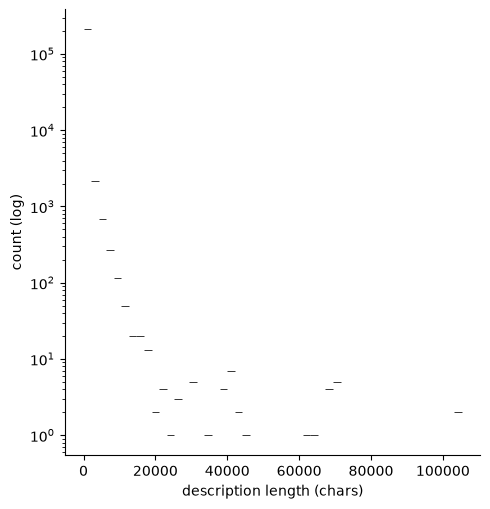

In [18]:
# Linear x + equal-width bins looks broken on this data: median is ~225 chars,
# but a few outliers go to ~100k, so almost all mass collapses into the first bin.
sns.displot(description_len.to_series(), bins=50, log_scale=(False, True))
plt.xlabel("description length (chars)")
plt.ylabel("count (log)")
plt.show()  